# 2. Poisson Regression

The dataset bikes.csv contains daily bike rental counts. The variables are

- `temp`: temperature
- `humidity`: humudity level
- `windspeed`: wind speed
- `count`: number of bike rentals

We model the data using the Poisson regression model

$$
\begin{matrix}
    y_i \sim \text{Pois}(\lambda_i), 
    & \lambda_i = \exp(\langle \boldsymbol{\theta}, \mathbf{x}_i\rangle)
\end{matrix}
$$

(a) Load the dataset and plot a histogram of `count`. Explain why a Poisson model may be appropriate

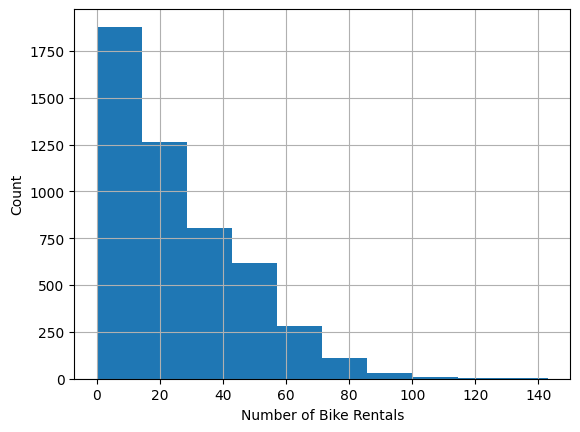

In [7]:
import pandas as pd
import matplotlib.pyplot as plt 

df: pd.DataFrame = pd.read_csv('./bikes.csv', sep=",")
plt.hist(df['count'])
plt.ylabel("Count")
plt.xlabel("Number of Bike Rentals")
plt.grid(True)
plt.show()

A Poisson model is appropriate for modelling `count` as from the historgram above, the variables 
appears to be displaying Poisson behaviour.

(b) Fit a Poisson regression model using the predictors

$$ \text{(temp, humidity, windspeed)} $$

In [8]:
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor

X: np.ndarray = df.iloc[:, :-1].to_numpy()
y: np.ndarray = df.iloc[:, -1].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model: PoissonRegressor = PoissonRegressor().fit(X_train, y_train)


(c) Interpret the coefficient of `temp`

In [10]:
print(f"Temp Coefficient: {np.exp(model.coef_[0]):.2f}")

Temp Coefficient: 1.07


The exponentiated coefficient of `temp`, otherwise called the Incident Rate Ratio indicates that 
values of `temp` lead to an increase in the expected `count`

(d) Use the fitted model to predict the expected number of retanls for

$$
\begin{matrix}
    \text{temp} = 25,
    & \text{humidity} = 50,
    & \text{windspeed} = 10
\end{matrix}
$$

In [14]:
prediction: np.ndarray = model.predict([[25, 50, 10]])
print(f"Prediction: {prediction[0]:.2f} expected number of bike rentals")

Prediction: 44.39 expected number of bike rentals


(e) Plot predicted counts versus observed counts

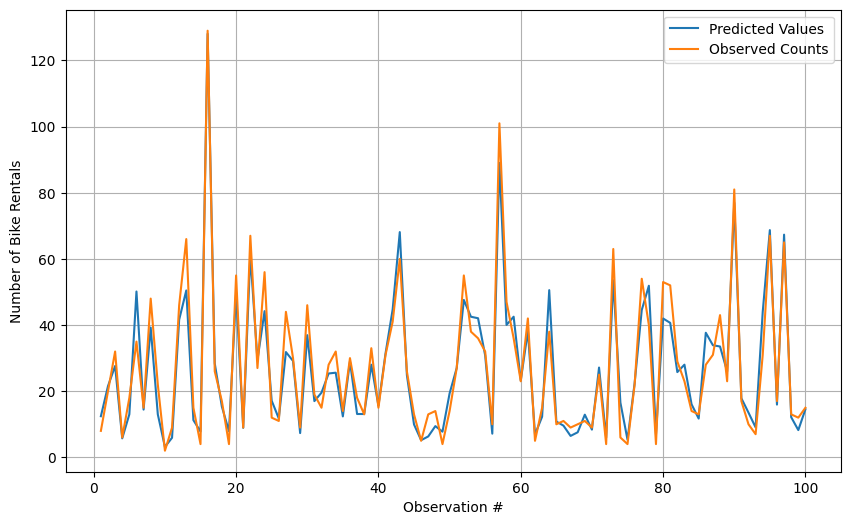

In [24]:
y_test_pred: np.ndarray = model.predict(X_test[:100])
observation_array: np.ndarray = np.arange(1, 101)

plt.figure(figsize=(10,6))
plt.plot(observation_array, y_test_pred, label="Predicted Values")
plt.plot(observation_array, y_test[:100], label="Observed Counts")
plt.legend()
plt.xlabel("Observation #")
plt.ylabel("Number of Bike Rentals")
plt.grid()
plt.show()